# Tip Data

## Description

A waiter recorded information about every tip he received over the course of several months working at a single restaurant.

## Format

A data table with 244 rows and 7 variables

## Details

- tip in dollars,
- bill in dollars,
- gender of the person paying the bill,
- whether there were smokers in the group,
- day of the week,
- time of day,
- group size.

In total, he recorded 244 tips. The data were published in a collection of case studies for business statistics (Bryant & Smith 1995).

### References

Bryant, P. G. and Smith, M (1995) Practical Data Analysis: Case Studies in Business Statistics. Homewood, IL: Richard D. Irwin Publishing:

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = sns.load_dataset("tips")

In [4]:
df['sex']=df['sex'].astype('category')
df['smoker']=df['smoker'].astype('category')
df['day']=df['day'].astype('category')
df['time']=df['time'].astype('category')
print(*df.dtypes)

float64 float64 category category category category int64


In [5]:
print(*df.isna().any())

False False False False False False False


In [6]:
df.sort_values(by='tip').head()

,total_bill,tip,sex,smoker,day,time,size
92,5.75,1.00,Female,Yes,Fri,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1
67,3.07,1.00,Female,Yes,Sat,Dinner,1
236,12.60,1.00,Male,Yes,Sat,Dinner,2
0,16.99,1.01,Female,No,Sun,Dinner,2


In [7]:
df.sort_values(by='total_bill', ascending = False).head(3)

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4


## Univariate non-graphical exploratory data analysis

In [8]:
df.describe(include=['category'])

,sex,smoker,day,time
count,244,244,244,244
unique,2,2,4,2
top,Male,No,Sat,Dinner
freq,157,151,87,176


In [9]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


# Correlations

# 1. Total bill [USD] vs. Tips [USD]

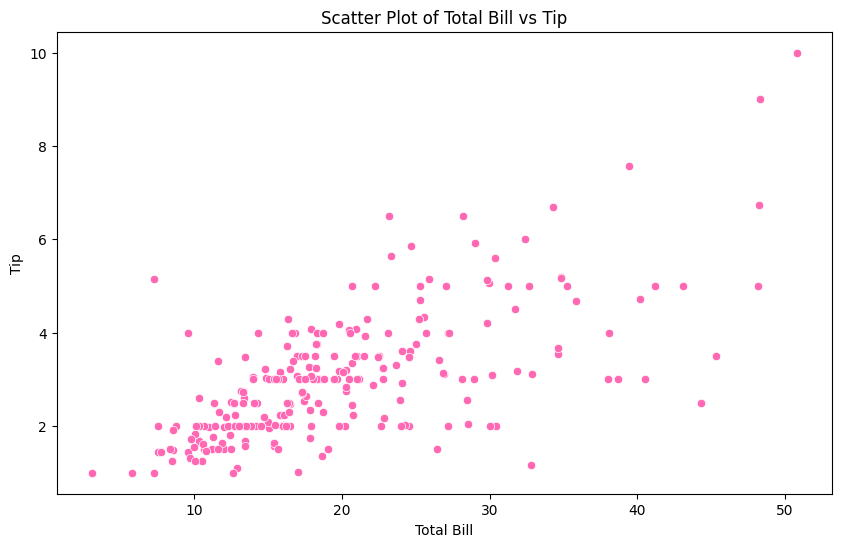

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x='total_bill', y='tip', data=df, ax=ax, color='hotpink')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Tip')
ax.set_title('Scatter Plot of Total Bill vs Tip')
plt.show()

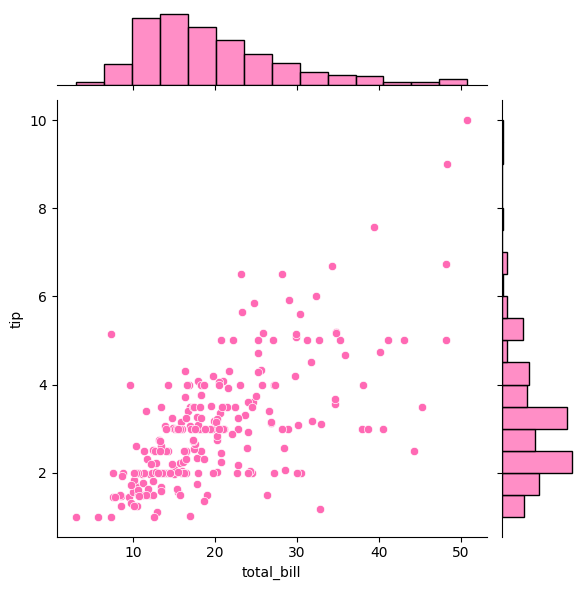

In [24]:
sns.jointplot(x='total_bill', y='tip', data=df, color='hotpink') 

In [17]:
from scipy.stats import pearsonr
log_bills = np.log(df['total_bill'])
log_tip = np.log(df['tip'])
pearsonr(log_bills, log_tip)

PearsonRResult(statistic=np.float64(0.6795702560274505), pvalue=np.float64(2.0794565165372116e-34))

# 2. Tips [USD] vs. Group size

<Axes: xlabel='size', ylabel='tip'>

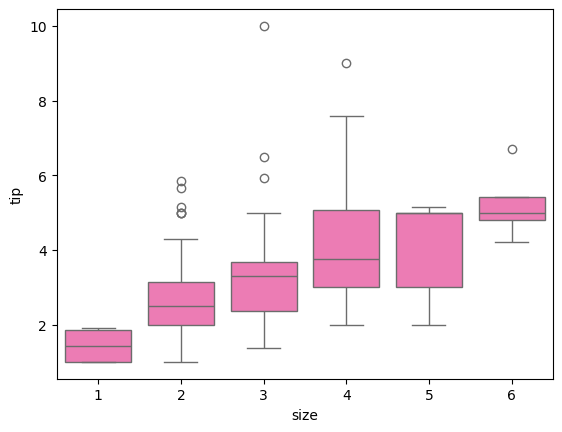

In [22]:
sns.boxplot(x='size', y='tip', data=df, color='hotpink')

In [26]:
from scipy.stats import kendalltau, spearmanr
kendalltau(df['size'], log_tip)

SignificanceResult(statistic=np.float64(0.3781847296598378), pvalue=np.float64(7.302407699520677e-14))

In [27]:
from scipy.stats import kendalltau, spearmanr
spearmanr(df['size'], log_tip)

SignificanceResult(statistic=np.float64(0.46826792926211475), pvalue=np.float64(1.059850307726079e-14))

# 3. Using the tips dataset, investigate the association between pairs of categorical variables.

Select suitable pairs of qualitative variables (e.g., sex, smoker, day, time) and:

- Create contingency tables.
- Visualize the relationships using count plots or stacked bar charts.
- Perform a Chi-square test of independence.
- Calculate an appropriate measure of association for categorical variables:
  - Phi coefficient (for 2×2 tables)
  - Cramér’s V (for larger contingency tables)
- Interpret the strength and practical meaning of the relationships.

Text(0.5, 1.0, 'Count of Smokers and Non-Smokers by Time of Day')

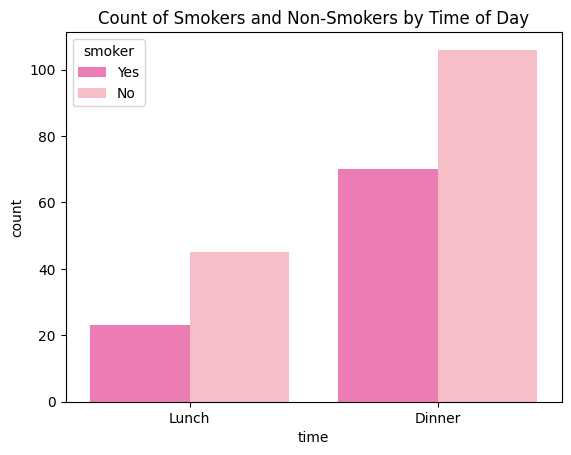

In [38]:
sns.countplot(data=df,x='time', hue='smoker', palette=['hotpink', 'lightpink'])
plt.title('Count of Smokers and Non-Smokers by Time of Day')

In [35]:
ct1= pd.crosstab(df['time'], df['smoker'])
ct1

smoker,Yes,No
time,,
Lunch,23,45
Dinner,70,106


In [39]:
from scipy.stats import chi2_contingency
chi2_contingency(ct1)

Chi2ContingencyResult(statistic=np.float64(0.5053733928754354), pvalue=np.float64(0.4771485672079724), dof=1, expected_freq=array([[ 25.91803279,  42.08196721],
       [ 67.08196721, 108.91803279]]))

In [ ]:
from scipy.stats.contingency import association
#association(ct1, method='cramer')
association(ct1) 

0.054921103595707566